# Satellite Image Classification — Deep Learning Model

---

## 1. Project Description

### Dataset
The dataset used for this project is **Satellite Image Classification** from Kaggle, containing satellite images categorized into four distinct classes.

- **Source:** https://www.kaggle.com/datasets/mahmoudreda55/satellite-image-classification
- **Number of Images:** Initially ~5600 images (4505 training, 1126 validation)
- **Classes:** Cloudy, Desert, Green Area, Water

### Problem Statement
The goal is to classify satellite images into one of four environmental categories: Cloudy, Desert, Green Area, or Water. This is a **multi-class image classification** problem.

### Machine Learning Solution
A Convolutional Neural Network (CNN) model is built and trained using TensorFlow/Keras to perform image classification. Key aspects of the solution include:
- **Data Augmentation:** Extensive use of `ImageDataGenerator` to create varied training samples and enhance model robustness.
- **Regularization:** Implementation of Dropout layers to prevent overfitting.
- **Early Stopping:** Utilizing Keras's `EarlyStopping` callback to monitor validation loss and stop training when performance no longer improves, restoring the best model weights.

### Performance Target
Validation Accuracy ≥ **0.90** on the evaluation data.

### Data Preprocessing & Augmentation Methods
- **Rescaling:** Images are rescaled to a range of 0-1.
- **Rotation:** `rotation_range=30`
- **Horizontal Flip:** `horizontal_flip=True`
- **Shear:** `shear_range=0.2`
- **Zoom:** `zoom_range=0.2`
- **Width/Height Shift:** `width_shift_range=0.2`, `height_shift_range=0.2`
- **Fill Mode:** `fill_mode='nearest'`
- **Validation Split:** `validation_split=0.2`

### Model Architecture
Deep Convolutional Neural Network (CNN):
- Conv2D (16 filters, 3x3) + MaxPooling (2x2)
- Conv2D (32 filters, 3x3) + MaxPooling (2x2)
- Conv2D (64 filters, 3x3) + MaxPooling (2x2)
- Flatten layer
- Dropout (0.3)
- Dense (128 neurons, ReLU activation)
- Dense (4 neurons, Softmax activation for multi-class output)
- **Optimizer:** Adam (learning_rate=0.001)
- **Loss:** Categorical Crossentropy

### Evaluation Metrics
- **Accuracy** (primary metric, target ≥ 0.90)
- **Loss** (Categorical Crossentropy)

## 2. Kaggle API Setup

In [60]:
! pip install kaggle

In [61]:
! mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


### 2.2 Configure Kaggle Credentials

This section sets up your Kaggle API credentials by creating the necessary directory, copying your `kaggle.json` file, and setting appropriate permissions. This allows the notebook to download datasets from Kaggle.

In [62]:
! cp kaggle.json ~/.kaggle/

In [63]:
! chmod 600 ~/.kaggle/kaggle.json

In [64]:
! kaggle datasets download mahmoudreda55/satellite-image-classification

Dataset URL: https://www.kaggle.com/datasets/mahmoudreda55/satellite-image-classification
License(s): copyright-authors
satellite-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


### 2.3 Download Dataset

This command uses the Kaggle API to download the 'satellite-image-classification' dataset by mahmoudreda55.

In [65]:
import zipfile,os
local_zip = '/content/satellite-image-classification.zip'
zip_ref = zipfile.ZipFile(local_zip,'r')
zip_ref.extractall('/content')
zip_ref.close()

## 3. Data Preparation

### 3.1 Extract Dataset

This cell extracts the downloaded `.zip` file into the `/content` directory, making the images accessible for training and validation.

In [66]:
# This cell is superseded by h3_DBbl8uAI8 and is now empty to avoid redundancy.

### 3.2 Setup Data Directories

These lines define the base directory where the extracted data resides and sets up paths for the training and validation image sets. The previous assignment of `train_data`, `validation_data`, `test_data` was removed as they were not directly used by `ImageDataGenerator` and could cause confusion.

In [67]:
base_dir = '/content/data'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'val')
# The variables train_data, validation_data, test_data are not used by ImageDataGenerator
# and were assigned incorrectly. Removing them to prevent confusion.

In [68]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_data_generator = ImageDataGenerator(
                    rescale=1./255,
                    rotation_range=30,
                    horizontal_flip=True,
                    shear_range = 0.2,
                    zoom_range=0.2, # Added zoom range
                    width_shift_range=0.2, # Added width shift range
                    height_shift_range=0.2, # Added height shift range
                    fill_mode = 'nearest',
                    validation_split=0.2,)

### 3.3 Configure Data Augmentation and Preprocessing

This section initializes an `ImageDataGenerator` for the training data. It includes various augmentation techniques like rescaling, rotation, horizontal flipping, shearing, zooming, and shifting to create a more robust model and prevent overfitting. `validation_split` is also defined here.

In [69]:
training_generator = train_data_generator.flow_from_directory(
        base_dir,
        target_size=(150, 150),
        color_mode = "rgb",
        class_mode = "categorical",
        batch_size = 16,
        seed = 0,
        shuffle = True,
        subset='training')

validation_generator = train_data_generator.flow_from_directory(
        base_dir,
        target_size=(150, 150),
        color_mode = "rgb",
        class_mode = "categorical",
        seed = 0,
        shuffle = False,
        subset='validation')

Found 4505 images belonging to 4 classes.
Found 1126 images belonging to 4 classes.


### 3.4 Create Data Generators

Using the configured `ImageDataGenerator`, this cell creates `training_generator` and `validation_generator` objects. These generators will feed image data to the model in batches, applying the specified augmentations and preprocessing steps.

In [70]:
# Define the CNN model architecture

import tensorflow as tf
model = tf.keras.models.Sequential([
                                    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(150, 150, 3)),
                                    tf.keras.layers.MaxPooling2D(2,2),
                                    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
                                    tf.keras.layers.MaxPooling2D(2,2),
                                    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
                                    tf.keras.layers.MaxPooling2D(2,2),
                                    tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dropout(0.3), # Increased dropout rate
                                    tf.keras.layers.Dense(128, activation='relu'),
                                    tf.keras.layers.Dense(4, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     2,367,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,391,716 (9.12 MB)

 Trainable params: 2,391,716 (9.12 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Model Definition

### 4.1 Define Convolutional Neural Network (CNN) Model Architecture

This section defines the structure of the CNN model using TensorFlow's Keras Sequential API. It consists of multiple convolutional layers with MaxPooling for feature extraction, followed by a Flatten layer, a Dropout layer for regularization, and dense layers for classification.

In [71]:
model.compile(loss='categorical_crossentropy',
              optimizer= tf.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

### 4.2 Compile the Model

Before training, the model needs to be compiled. This involves specifying the optimizer (Adam), the loss function (`categorical_crossentropy` for multi-class classification), and the metrics to monitor (accuracy).

In [72]:
from tensorflow.keras.callbacks import EarlyStopping

# Using Keras's built-in EarlyStopping callback for better control
# Monitor 'val_loss' and stop if it doesn't improve for 'patience' epochs.
callbacks = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=5,         # Stop if val_loss doesn't improve for 5 epochs
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)


## 5. Model Training and Evaluation

### 5.1 Configure Early Stopping Callback

This cell defines an `EarlyStopping` callback. This callback monitors a specified metric (e.g., `val_loss`) and stops training if no improvement is observed for a certain number of epochs (`patience`). It also restores the best model weights found during training, preventing overfitting and saving computational resources.

In [73]:
history = model.fit(
      training_generator,
      steps_per_epoch=len(training_generator), # Corrected steps_per_epoch to use full training set
      epochs=20,
      validation_data=validation_generator,
      validation_steps=len(validation_generator), # Corrected validation_steps to use full validation set
      verbose=2,
      callbacks = [callbacks]
      )

Epoch 1/20
282/282 - 45s - 158ms/step - accuracy: 0.7234 - loss: 0.5576 - val_accuracy: 0.8250 - val_loss: 0.4317
Epoch 2/20
282/282 - 36s - 128ms/step - accuracy: 0.8406 - loss: 0.3870 - val_accuracy: 0.8206 - val_loss: 0.3807
Epoch 3/20
282/282 - 37s - 132ms/step - accuracy: 0.8364 - loss: 0.3790 - val_accuracy: 0.8348 - val_loss: 0.3723
Epoch 4/20
282/282 - 35s - 126ms/step - accuracy: 0.8577 - loss: 0.3408 - val_accuracy: 0.8464 - val_loss: 0.4057
Epoch 5/20
282/282 - 37s - 132ms/step - accuracy: 0.8750 - loss: 0.3128 - val_accuracy: 0.8819 - val_loss: 0.2992
Epoch 6/20
282/282 - 40s - 140ms/step - accuracy: 0.8733 - loss: 0.3072 - val_accuracy: 0.8552 - val_loss: 0.3370
Epoch 7/20
282/282 - 37s - 132ms/step - accuracy: 0.8897 - loss: 0.2771 - val_accuracy: 0.8801 - val_loss: 0.3152
Epoch 8/20
282/282 - 35s - 125ms/step - accuracy: 0.8959 - loss: 0.2597 - val_accuracy: 0.8597 - val_loss: 0.3054
Epoch 9/20
282/282 - 37s - 132ms/step - accuracy: 0.8872 - loss: 0.2758 - val_accuracy: 

### 5.2 Train the Model

This cell initiates the training process. The model is fitted using the `training_generator` and `validation_generator`, with the specified number of epochs and the `EarlyStopping` callback to manage the training duration dynamically.

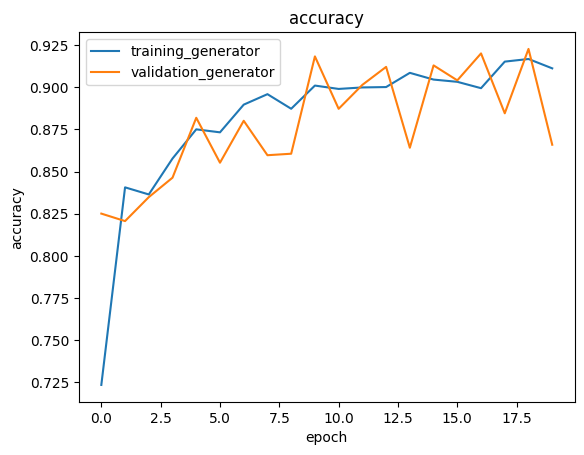

In [74]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training_generator', 'validation_generator'], loc='upper left')
plt.show()

### 5.3 Visualize Training and Validation Accuracy

This plot shows the trend of training accuracy versus validation accuracy over the epochs. It helps in assessing if the model is learning effectively and if there are signs of overfitting or underfitting.

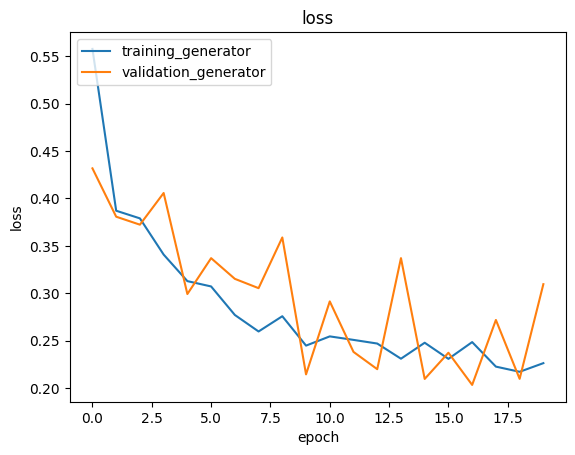

In [75]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training_generator', 'validation_generator'], loc='upper left')
plt.show()

### 5.4 Visualize Training and Validation Loss

This plot displays the training loss and validation loss over the epochs. Observing these trends is crucial for understanding the model's convergence and identifying potential issues like high bias or high variance.

### 5.5 Improving Model Performance: Addressing Overfitting and Underfitting

Based on the training history plots, your model is performing quite well, with both training and validation accuracy surpassing 85% and training stopping early. However, here are some general strategies you can consider to further optimize your model and mitigate potential overfitting or underfitting:

**To address potential overfitting (when the model performs well on training data but poorly on unseen validation data):**

1.  **Increase Data Augmentation:** You are already using `ImageDataGenerator` with `rotation_range`, `horizontal_flip`, `shear_range`, and `fill_mode`. You could experiment with more aggressive augmentation parameters or add other techniques like `zoom_range`, `width_shift_range`, or `height_shift_range` to create more diverse training samples.
2.  **Regularization:** You have a `Dropout` layer. You could try increasing the dropout rate (e.g., from 0.2 to 0.3 or 0.4) or add more dropout layers. You could also introduce L1 or L2 regularization to your convolutional or dense layers.
3.  **Simplify the Model:** If overfitting becomes more apparent, you might consider reducing the number of filters in your convolutional layers or reducing the number of neurons in your dense layers.
4.  **Early Stopping Criteria:** Your current early stopping condition (`accuracy > 0.85 and val_accuracy > 0.85`) is good for stopping when the model reaches a certain performance. However, if the validation accuracy starts to drop after reaching a peak while training accuracy continues to rise, you might want to use a `patience` parameter with `EarlyStopping` callback to monitor `val_loss` or `val_accuracy` for a few epochs before stopping.
5.  **Review `validation_steps`:** Your `validation_steps` is set to `2`. This means validation metrics are calculated on only 2 batches (32 images). A small `validation_steps` can lead to very noisy and unstable validation metrics, making it harder to accurately judge overfitting or underfitting. It's generally recommended to set `validation_steps` to `len(validation_generator)` or a sufficiently large number to cover a good portion of your validation set.

**To address potential underfitting (when the model performs poorly on both training and validation data):**

1.  **Increase Model Complexity:** If your model struggles to learn the patterns in the data, you could try adding more convolutional layers, increasing the number of filters, or adding more neurons to your dense layers.
2.  **More Training Epochs:** If the accuracy is still improving on both training and validation sets when early stopping triggers, you might want to allow the model to train for more epochs (e.g., by adjusting the early stopping threshold or removing the callback temporarily).
3.  **Adjust Learning Rate:** A learning rate that is too low can cause the model to converge very slowly. Experimenting with a slightly higher learning rate or using learning rate schedulers could help.
4.  **Feature Engineering (less common for images):** While not typically done directly on raw image pixels, ensuring your image preprocessing is effective and not discarding useful information is crucial.

Given your current output, the `validation_steps=2` is a significant point to review, as it might be providing an unreliable estimate of validation performance. Increasing this value would give a more stable picture of your model's generalization ability.

In [76]:
# import numpy as np
# from google.colab import files
# from keras.preprocessing import image
# import matplotlib.pyplot as plt
# import matplotlib.image as mpimg
# %matplotlib inline

# uploaded = files.upload()

# for fn in uploaded.keys():

#   # memprediksi gambar
#   path = fn
#   img = image.load_img(path, target_size=(150,150))
#   imgplot = plt.imshow(img)
#   x = image.img_to_array(img)
#   x = np.expand_dims(x, axis=0)

#   images = np.vstack([x])
#   classes = model.predict(images, batch_size=10)

#   print("\n")
#   print('Hasil Prediksi : ',classes[0],'\n')

#   print(fn)
#   if classes[0][0] == 1:
#     print( "cloudy")
#   elif classes[0][1] == 1:
#     print("desert")
#   elif classess[0][2] == 1 :
#     print("green_area")
#   else :
#     print("water")

## 6. Model Deployment & Utility

### 6.1 Prediction Example (Uncomment to use)

This section provides commented-out code for making predictions on new, uploaded images. It preprocesses the image and uses the trained model to classify it into one of the satellite image categories.

In [77]:
# # save using TFlite
# import tensorflow as tf

# converter = tf.lite.TFLiteConverter.from_keras_model(model)
# tflite_model = converter.convert()

# with open('RPS_model.tflite', 'wb') as f:
#   f.write(tflite_model)

### 6.2 Convert Model to TFLite (Uncomment to use)

This commented-out code demonstrates how to convert the trained Keras model into a TensorFlow Lite (`.tflite`) format. This format is optimized for deployment on mobile devices and edge devices.

In [78]:
model.save('model-example.h5')

### 6.3 Save the Trained Model

This cell saves the trained model to an HDF5 file (`.h5`). This allows you to load and reuse the model later without retraining. Note the warning about using the newer Keras native format (`.keras`) for future compatibility.